# From Text to Sentiment: Deep Learning on Yelp Reviews

## Introduction

In this notebook, we explore the Yelp review dataset to perform sentiment analysis using natural language processing (NLP) techniques.

The dataset contains user-generated reviews along with star ratings, providing a rich source of textual data for understanding customer opinions. To simplify the problem, we focus on a binary classification task by selecting only 1-star (negative) and 5-star (positive) reviews.

The workflow includes text cleaning, preprocessing, tokenization, and vectorization using techniques such as CountVectorizer. We then transform the text data into numerical features suitable for machine learning models.

This project demonstrates how raw textual data can be converted into meaningful insights and used to build predictive models for sentiment classification.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import accuracy_score
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2026-04-20 21:41:42.103542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776721302.334443      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776721302.405995      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776721302.955214      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776721302.955259      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776721302.955263      16 computation_placer.cc:177] computation placer alr

In [2]:
df=pd.read_csv('/kaggle/input/datasets/farukalam/yelp-restaurant-reviews/Yelp Restaurant Reviews.csv')

In [3]:
df.head()

,Yelp URL,Rating,Date,Review Text
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...


In [4]:
df=df.drop(['Yelp URL','Date'],axis=1)

In [5]:
df.head()

,Rating,Review Text
0,5,All I can say is they have very good ice cream...
1,4,Nice little local place for ice cream.My favor...
2,5,A delicious treat on a hot day! Staff was very...
3,4,This was great service and a fun crew! I got t...
4,5,This is one of my favorite places to get ice c...


In [6]:
df.columns=['stars','text']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19896 entries, 0 to 19895
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   stars   19896 non-null  int64 
 1   text    19896 non-null  object
dtypes: int64(1), object(1)
memory usage: 311.0+ KB


In [8]:
df.shape

(19896, 2)

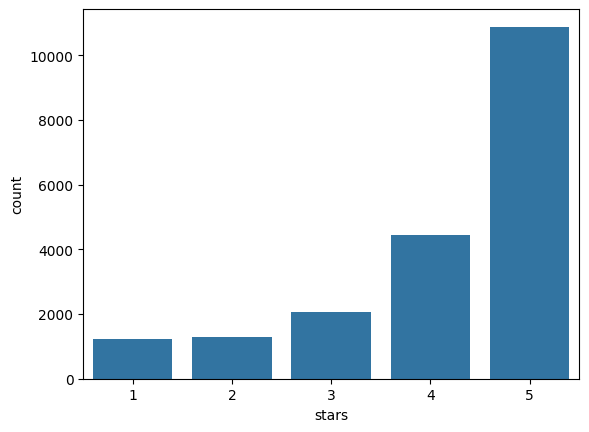

In [9]:
sns.countplot(x=df['stars']);

In [10]:
df['stars'].value_counts()

stars
5    10883
4     4447
3     2069
2     1280
1     1217
Name: count, dtype: int64

In [11]:
# Text Preprocessing

df['text'] = df['text'].str.lower()  
# Normalize text by converting all characters to lowercase

df['text'] = df['text'].str.replace('[^\w\s]', '', regex=True)  
# Remove punctuation and special characters

df['text'] = df['text'].str.replace('\d+', '', regex=True)  
# Remove numerical values

df['text'] = df['text'].str.replace('\n', '', regex=True)  
# Remove newline characters

df['text'] = df['text'].str.replace('\r', '', regex=True)  
# Remove carriage return characters

<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_16/469518970.py:6: SyntaxWarning: invalid escape sequence '\w'
  df['text'] = df['text'].str.replace('[^\w\s]', '', regex=True)
/tmp/ipykernel_16/469518970.py:9: SyntaxWarning: invalid escape sequence '\d'
  df['text'] = df['text'].str.replace('\d+', '', regex=True)


In [12]:
ybw = df[(df.stars == 1) | (df.stars == 5)]

In [13]:
ybw = ybw.reset_index(drop=True)
# Resets the index of the filtered DataFrame and removes the old index

In [14]:
x = ybw['text']
y = ybw[['stars']]

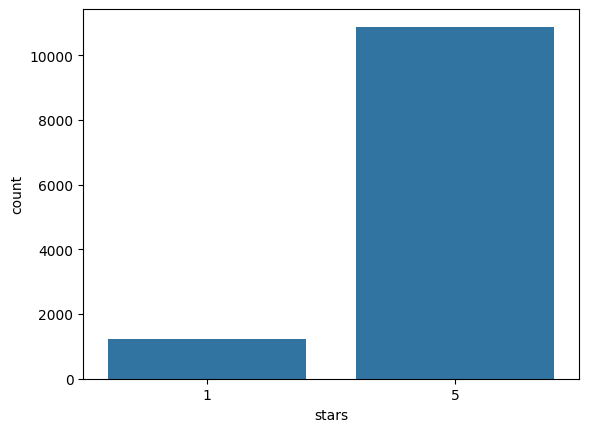

In [15]:
sns.countplot(x=y['stars']);

In [16]:
 y.loc[:, 'stars'] = y['stars'].map({1: 0, 5: 1})
# Defined the target variable as a binary class (0 and 1) for machine learning models
# 1 star → 0 (negative), 5 stars → 1 (positive)

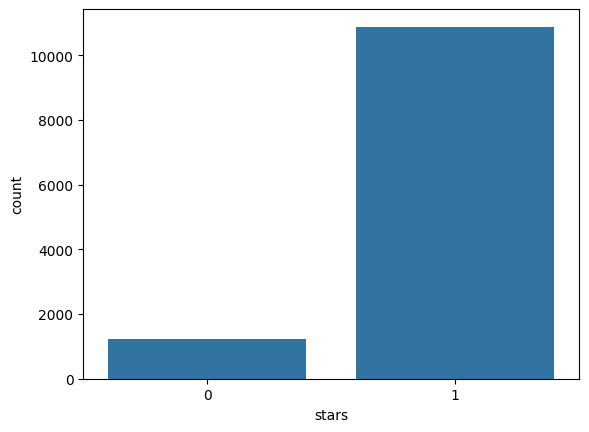

In [17]:
sns.countplot(x=y['stars']);

In [18]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words]
# Splits the text into tokens and converts each word to its base (lemma) form

In [19]:
x.head()

0    all i can say is they have very good ice cream...
1    a delicious treat on a hot day staff was very ...
2    this is one of my favorite places to get ice c...
3    ive been coming to this ice cream stand since ...
4    the softserve is way too sweet and has a stran...
Name: text, dtype: object

In [20]:
from sklearn.feature_extraction.text import CountVectorizer 
# Imports CountVectorizer, which transforms text documents into a matrix of token counts (numerical vectors)

In [21]:
vect = CountVectorizer(stop_words='english', analyzer=ekkok, ngram_range=(1,2))  
# Text vectorization configuration:
# - Uses lemmatization to normalize words to their base forms
# - Removes common English stopwords to reduce noise
# - Includes both unigrams and bigrams to capture contextual word relationships

x_vect = vect.fit_transform(x).toarray()  
# Transforms text documents into numerical feature vectors and stores the result as a NumPy array

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [22]:
x_vect.shape

(12100, 18012)

In [23]:
tf = pd.DataFrame(vect.fit_transform(x).toarray(),columns=vect.get_feature_names_out())
# Converts the transformed numerical data into a Pandas DataFrame for further analysis
# Assigns feature names from the vectorizer's learned vocabulary as column names
# Each column corresponds to a token (word/ngram), and each row represents a document

In [24]:
tf

,a,aa,aaa,aaaaaaahhhhhhmazing,aaaaaamazing,aaaaaand,aaaah,aaaand,aaah,aaamazing,...,zuul,ºf,¼,¼¼,¼¼¼,ã,ãclair,ãcrire,ã¼ber,ï½ž
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12095,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12096,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12097,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12098,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_vect, y, test_size=0.2, random_state=42)  

In [26]:
model = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # classification 0 or 1
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  

2026-04-20 21:42:38.586063: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [27]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), verbose=2, epochs=15)  

Epoch 1/15
303/303 - 14s - 46ms/step - accuracy: 0.9504 - loss: 0.1408 - val_accuracy: 0.9686 - val_loss: 0.0743
Epoch 2/15
303/303 - 11s - 37ms/step - accuracy: 0.9907 - loss: 0.0266 - val_accuracy: 0.9698 - val_loss: 0.0864
Epoch 3/15
303/303 - 11s - 35ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9707 - val_loss: 0.1238
Epoch 4/15
303/303 - 11s - 36ms/step - accuracy: 0.9981 - loss: 0.0082 - val_accuracy: 0.9736 - val_loss: 0.1328
Epoch 5/15
303/303 - 11s - 35ms/step - accuracy: 0.9983 - loss: 0.0053 - val_accuracy: 0.9719 - val_loss: 0.1593
Epoch 6/15
303/303 - 11s - 35ms/step - accuracy: 0.9974 - loss: 0.0088 - val_accuracy: 0.9731 - val_loss: 0.1090
Epoch 7/15
303/303 - 11s - 35ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9740 - val_loss: 0.1480
Epoch 8/15
303/303 - 11s - 35ms/step - accuracy: 0.9998 - loss: 6.2470e-04 - val_accuracy: 0.9760 - val_loss: 0.1591
Epoch 9/15
303/303 - 11s - 35ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.976

In [28]:
model.evaluate(x_test, y_test) 

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9768 - loss: 0.3292


[0.27516433596611023, 0.9731404781341553]

In [29]:
neg = df[df['stars'] == 1]['text'].iloc[0]
# Selects the first negative review (1-star rating) from the DataFrame

In [30]:
len(neg)

234

In [31]:
pos = df[df['stars'] == 5]['text'].iloc[0]

In [32]:
len(pos)

123

In [33]:
result1 = vect.transform([pos]).toarray()
# Converts the positive review into a numerical feature vector using the pre-fitted CountVectorizer

In [34]:
result1.shape

(1, 18012)

In [35]:
p = model.predict(result1)  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [36]:
p
# Outputs the model's predicted probability for the positive class
# The probability ranges from 0 to 1, where values > 0.5 indicate a positive prediction and values < 0.5 indicate a negative prediction

array([[0.9999584]], dtype=float32)

In [37]:
label = ['Negative', 'Positive']

In [38]:
label[1 if p > 0.5 else 0]

'Positive'

In [39]:
model.save('sentiment.keras')

## Text Cleaning and Preprocessing with NeatText in Python

In [40]:
pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
import neattext.functions as nfx  

In [42]:
dir(nfx)

['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

In [43]:
df.shape

(19896, 2)

In [44]:
s = ' '.join(df.text)

In [45]:
from collections import Counter

In [46]:
Counter(s.split())

Counter({'all': 6638,
         'i': 50899,
         'can': 4091,
         'say': 1638,
         'is': 23750,
         'they': 15456,
         'have': 11411,
         'very': 5663,
         'good': 8490,
         'ice': 16075,
         'cream': 17493,
         'would': 4155,
         'for': 18692,
         'sure': 1611,
         'recommend': 1683,
         'their': 7568,
         'cookies': 2328,
         'and': 60224,
         'creme': 633,
         'it': 25956,
         'nice': 2463,
         'little': 3568,
         'local': 665,
         'place': 9413,
         'creammy': 1,
         'favorite': 2272,
         'pumpkin': 282,
         'shake': 485,
         'fall': 114,
         'season': 90,
         'special': 799,
         'my': 15134,
         'sweetness': 301,
         'tolerance': 3,
         'low': 119,
         'large': 616,
         'size': 647,
         'usually': 670,
         'seems': 352,
         'too': 3992,
         'sweet': 4386,
         'after': 2626,
         'ha

In [47]:
s2 = nfx.remove_stopwords(s)

In [48]:
Counter(s2.split())

Counter({'good': 8490,
         'ice': 16075,
         'cream': 17493,
         'sure': 1611,
         'recommend': 1683,
         'cookies': 2328,
         'creme': 633,
         'nice': 2463,
         'little': 3568,
         'local': 665,
         'place': 9413,
         'creammy': 1,
         'favorite': 2272,
         'pumpkin': 282,
         'shake': 485,
         'fall': 114,
         'season': 90,
         'special': 799,
         'sweetness': 301,
         'tolerance': 3,
         'low': 119,
         'large': 616,
         'size': 647,
         'usually': 670,
         'sweet': 4386,
         'love': 4538,
         'pina': 3,
         'colada': 4,
         'refreshing': 189,
         'banana': 580,
         'split': 313,
         'delicious': 4543,
         'treat': 1035,
         'hot': 1009,
         'day': 2016,
         'staff': 2456,
         'friendly': 2447,
         'helpful': 664,
         'gave': 539,
         'sample': 509,
         'let': 841,
         'order': 21

In [49]:
data = Counter(s2.split()).most_common(20)

In [50]:
data = dict(data)
# Generates a dictionary containing the top 20 most frequent words and their corresponding frequencies

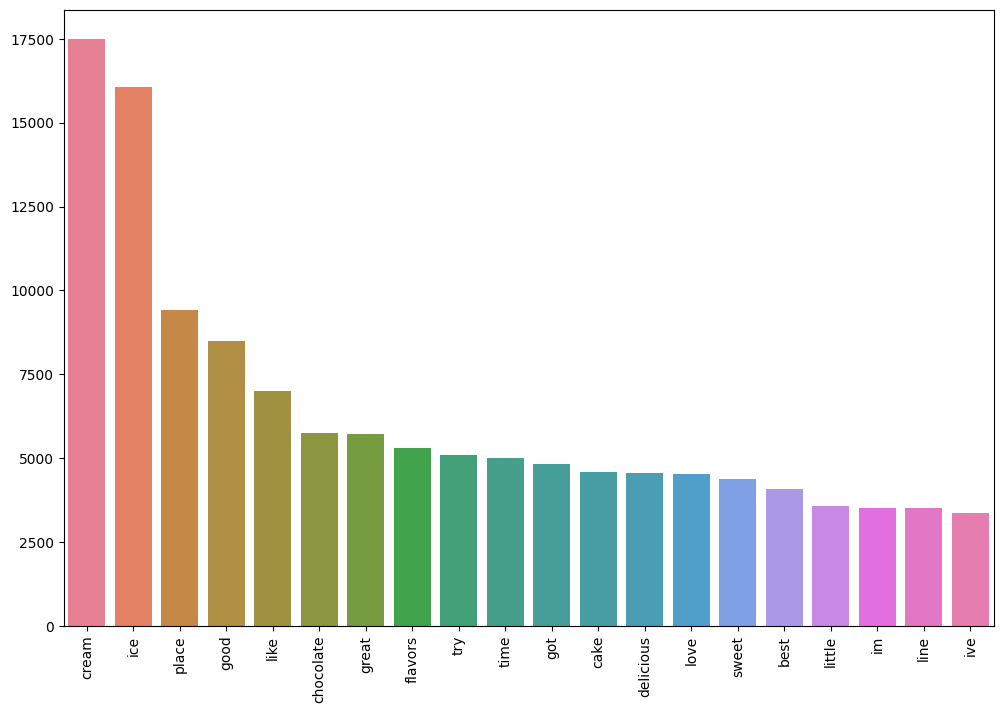

In [51]:
plt.figure(figsize=(12,8))  
sns.barplot(x=list(data.keys()), y=list(data.values()), hue=list(data.keys()))  
plt.xticks(rotation=90);  

In [52]:
bad = df[df['stars'] == 1]  

In [53]:
badsen = ' '.join(bad['text'])
# Concatenates all negative reviews into a single text string for further analysis

In [54]:
bs = nfx.remove_stopwords(badsen) 

In [55]:
Counter(bs.split()) 

Counter({'softserve': 1,
         'way': 163,
         'sweet': 119,
         'strange': 4,
         'splendalike': 1,
         'aftertaste': 7,
         'flavors': 83,
         'tasted': 189,
         'artificial': 11,
         'ended': 50,
         'stomach': 7,
         'ache': 2,
         'got': 353,
         'home': 59,
         'dont': 306,
         'recommend': 63,
         'place': 479,
         'simple': 24,
         'baskin': 3,
         'robbins': 4,
         'better': 215,
         'absolutely': 38,
         'awful': 46,
         'experience': 139,
         'hair': 33,
         'ice': 535,
         'cream': 614,
         'manager': 113,
         'super': 73,
         'rude': 129,
         'said': 258,
         'refunds': 1,
         'times': 78,
         'ive': 150,
         'boba': 18,
         'cooking': 4,
         'wont': 88,
         'mins': 40,
         'point': 51,
         'offering': 7,
         'tea': 24,
         'isnt': 45,
         'ready': 38,
         'maybe'

In [56]:
data = Counter(bs.split()).most_common(20)  

In [57]:
data = dict(data)

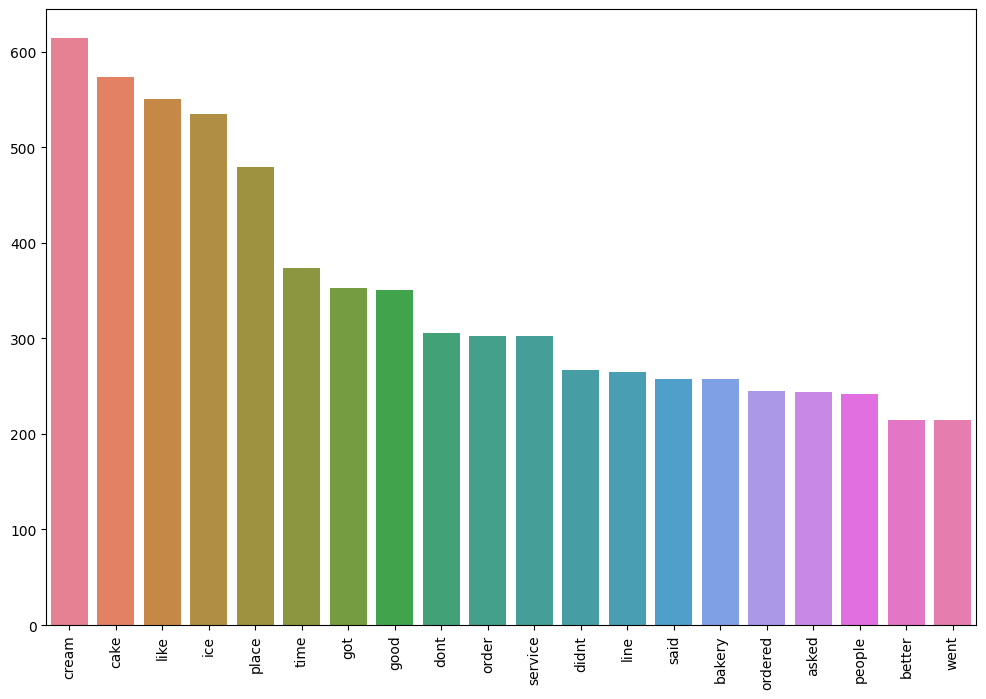

In [58]:
plt.figure(figsize=(12,8))  
sns.barplot(x=list(data.keys()), y=list(data.values()), hue=list(data.keys()))  
plt.xticks(rotation=90); 

In [59]:
good = df[df['stars'] == 5]  

In [60]:
goodsen=''.join(good['text'])

In [61]:
gs=nfx.remove_stopwords(goodsen)

In [62]:
Counter(gs.split())

Counter({'good': 3413,
         'ice': 9880,
         'cream': 10330,
         'sure': 690,
         'recommend': 968,
         'cookies': 902,
         'creme': 305,
         'gooda': 1,
         'delicious': 2758,
         'treat': 574,
         'hot': 501,
         'day': 933,
         'staff': 1417,
         'friendly': 1582,
         'helpful': 415,
         'gave': 207,
         'sample': 283,
         'let': 456,
         'order': 744,
         'little': 1656,
         'earlier': 51,
         'openthis': 1,
         'favorite': 1544,
         'places': 478,
         'cu': 13,
         'area': 740,
         'bit': 493,
         'drive': 283,
         'worth': 1363,
         'minutes': 249,
         'far': 406,
         'urbana': 9,
         'getting': 419,
         'easy': 159,
         'atmosphere': 369,
         'dairy': 261,
         'barn': 8,
         'kid': 121,
         'tables': 165,
         'set': 92,
         'sit': 265,
         'enjoy': 484,
         'friends': 505,


In [63]:
data=Counter(gs.split()).most_common(20)

In [64]:
data=dict(data)

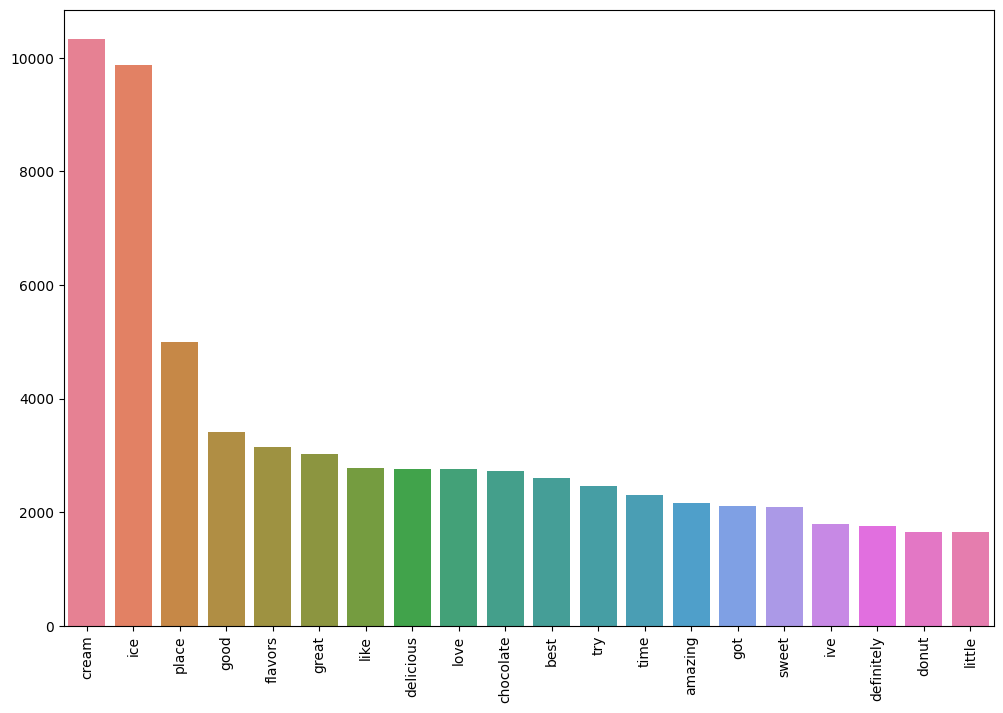

In [65]:
plt.figure(figsize=(12,8))
sns.barplot(x=data.keys(),y=data.values(),hue=data.keys())
plt.xticks(rotation=90);

## Conclusion

In this project, we developed a deep learning model to perform sentiment analysis on Yelp reviews.

By focusing on 1-star and 5-star reviews, we framed the problem as a binary classification task. After applying text preprocessing techniques such as cleaning, normalization, tokenization, and vectorization, the model was able to learn meaningful patterns from the data.

The deep learning model achieved strong performance, reaching approximately 97% accuracy, which demonstrates its ability to effectively distinguish between positive and negative sentiments.

This project highlights the importance of proper text preprocessing and feature representation when working with NLP tasks. It also shows how deep learning models can successfully handle large-scale textual data and extract valuable insights from customer reviews.

Overall, this work provides a solid foundation for building more advanced NLP applications, such as multi-class sentiment analysis, topic modeling, and real-world recommendation systems.